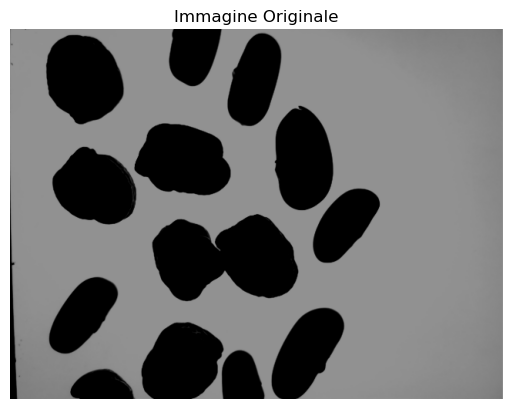

Pixel evitati: 98406 su 284592 totali
Percentuale di ottimizzazione: 34.58%


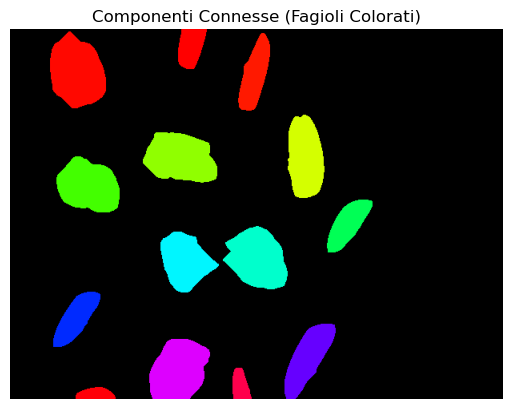

Tempo totale di esecuzione: 0.54 secondi
Numero di componenti connesse (fagioli): 14


In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

def find_boundaries(binary_image):
    """Identifies boundary pixels in a binary image using 4-connectivity."""
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for i in range(h):
        for j in range(w):
            if binary_image[i, j] == 255:  # Foreground pixel
                for dx, dy in directions:
                    ni, nj = i + dx, j + dy
                    if 0 <= ni < h and 0 <= nj < w and binary_image[ni, nj] == 0:
                        boundary_mask[i, j] = 255  # Mark as boundary
                        break  # Stop checking once confirmed
    return boundary_mask

def connected_components_labeling(binary_image):
    h, w = binary_image.shape
    labels = np.zeros((h, w), dtype=np.int32)
    label_equivalences = {}
    next_label = 1

    # ANALISI PRELIMINARE: Trova il bounding box dell'area di interesse
    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    total_pixels = h * w
    analyzed_pixels = (bottom - top) * (right - left)
    skipped_pixels = total_pixels - analyzed_pixels
    
    print(f"Pixel evitati: {skipped_pixels} su {total_pixels} totali")
    print(f"Percentuale di ottimizzazione: {skipped_pixels / total_pixels * 100:.2f}%")

    # Passo 1: Assegnazione etichette provvisorie SOLO nel bounding box
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255:
                neighbors = []
                if j > 0 and labels[i, j - 1] > 0:
                    neighbors.append(labels[i, j - 1])
                if i > 0 and labels[i - 1, j] > 0:
                    neighbors.append(labels[i - 1, j])

                if not neighbors:
                    labels[i, j] = next_label
                    label_equivalences[next_label] = next_label
                    next_label += 1
                else:
                    min_label = min(neighbors)
                    labels[i, j] = min_label
                    for n in neighbors:
                        if n != min_label:
                            label_equivalences[n] = min_label

    # Passo 2: Identificazione dei contorni
    boundary_mask = find_boundaries(binary_image)

    # Passo 3: Risoluzione etichette equivalenti
    for i in range(h):
        for j in range(w):
            if labels[i, j] > 0:
                root = labels[i, j]
                while root != label_equivalences[root]:
                    root = label_equivalences[root]
                labels[i, j] = root

    unique_labels = np.unique(labels)
    num_labels = len(unique_labels) - (1 if 0 in unique_labels else 0)
    
    # Creazione immagine colorata con sfondo nero
    label_hue = np.uint8(179 * labels / np.max(labels))
    labeled_img = cv2.merge([label_hue, np.full_like(label_hue, 255), np.full_like(label_hue, 255)])
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2RGB)
    labeled_img[labels == 0] = [0, 0, 0]  # Sfondo nero
    
    plt.imshow(labeled_img)
    plt.axis('off')
    plt.title("Componenti Connesse (Fagioli Colorati)")
    plt.show()
    
    return labels, num_labels, boundary_mask, skipped_pixels

# Avvio del timer
start_time = time.time()

# Carica l'immagine e convertila in scala di grigi
beans_img = cv2.imread('000005.bmp')
beans_img = cv2.cvtColor(beans_img, cv2.COLOR_BGR2RGB)
plt.imshow(beans_img)
plt.axis('off')
plt.title("Immagine Originale")
plt.show()

img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)

# Ritaglio dei bordi
height, width = img_gray.shape
border_x = int(height * 0.02)  
border_y = int(width * 0.02)   
img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]

# Segmentazione
threshold = 75
_, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)

# Operazioni Morfologiche
kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=15)

kernel_open = np.ones((3,3), np.uint8)
img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)

# Etichettatura componenti connesse e identificazione bordi
labels, num_labels, boundary_mask, skipped_pixels = connected_components_labeling(img_opened)

# Stampa tempo di esecuzione e pixel risparmiati
execution_time = time.time() - start_time
print(f"Tempo totale di esecuzione: {execution_time:.2f} secondi")
print(f"Numero di componenti connesse (fagioli): {num_labels}")
